In [67]:
import os
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, accuracy_score

In [68]:
def get_path():
    dir = os.getcwd()
    return dir

In [69]:
medical_data = pd.read_csv(get_path() + "//Data//diabetes.csv")

In [70]:
medical_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Summary is identified by using df.shape, df.info() & df.describe() functions. The Details can be seen below for each of the commands

In [71]:
medical_data.shape #The output indicates the number of rows & columns in the dataaset

(768, 9)

In [72]:
medical_data.info() #The output provides the datatype of each columns in the dataset

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [73]:
medical_data.describe() #The output provides statistical values like Standard Deviation, Mean etc.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


To check if the dataset if having any missing values, .isnull().sum() command is used. The output displays the sum of null values across each columns

In [74]:
medical_data.isnull().sum() #The output indicates no missing values in the dataset

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

The dataset has 8 input features & 1 target column. The input features & target columns are segregated into X & Y dataframe & series respectively

In [75]:
X = medical_data.drop('Outcome',axis=1)
Y = medical_data['Outcome']

In [76]:
X.shape, Y.shape

((768, 8), (768,))

The datasets X & Y are split into train & test dataset using Scikit library train_test_split method

In [77]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.85)

In [78]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((652, 8), (652,), (116, 8), (116,))

To understand the relation between input features and between an input feature and target, below plots are created. However, nothing much can be identified using these graphs

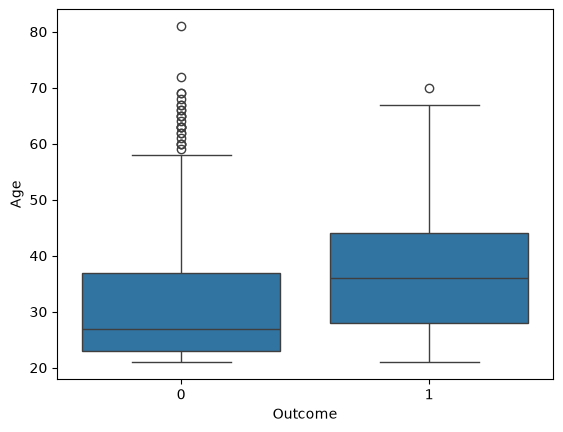

In [79]:
plot1 = sns.boxplot(data= medical_data, x = 'Outcome', y = 'Age')

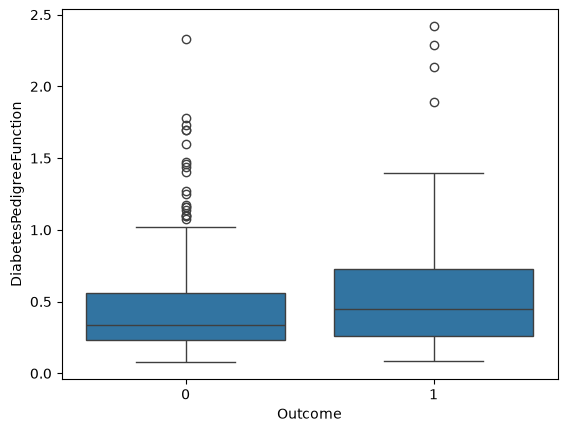

In [80]:
plot2 = sns.boxplot(data= medical_data, x = 'Outcome', y = 'DiabetesPedigreeFunction')

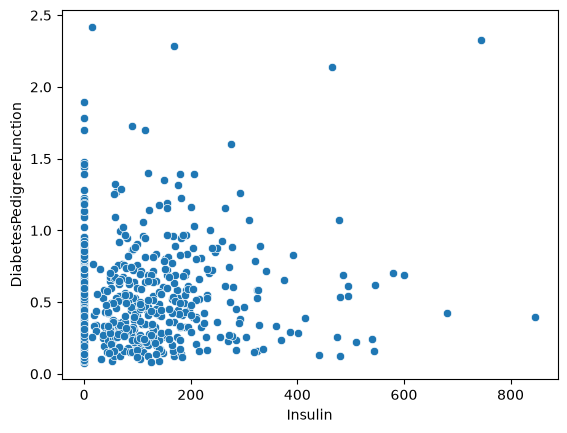

In [81]:
plot3 = sns.scatterplot(data = medical_data, x = 'Insulin', y = 'DiabetesPedigreeFunction' )

Below are the Data Preprocessing Steps - Using StandardScaler for Scaling down training dataset

In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [83]:
x_train_scaled = scaler.fit_transform(x_train)
x_train_scaled = pd.DataFrame(x_train_scaled, columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age'])
x_train_scaled.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,652.00,652.00,652.00,652.00,652.00,652.00,652.00,652.00
mean,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.15,-3.73,-3.60,-1.34,-0.69,-4.06,-1.20,-1.03
25%,-0.84,-0.67,-0.37,-1.34,-0.69,-0.59,-0.70,-0.78
50%,-0.24,-0.14,0.15,0.14,-0.37,0.02,-0.30,-0.36
75%,0.67,0.63,0.56,0.74,0.40,0.57,0.49,0.57
max,3.10,2.38,2.33,4.89,6.42,4.40,5.81,4.02


In [84]:
x_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.145066,-0.878147,-0.476643,-1.339549,-0.694156,0.388719,-0.642267,-0.695421
1,-0.539319,0.012196,-0.476643,-0.207161,0.197050,-0.304545,0.715696,-0.947879
2,2.489415,0.564822,0.668386,1.365601,2.038316,0.880305,0.150377,2.081617
3,1.883668,0.012196,0.460199,0.610675,-0.694156,-0.581850,0.102519,0.987632
4,0.975048,2.007792,-0.060269,1.113959,1.861756,0.691233,-0.669187,0.651022


Below are the Data Preprocessing Steps - Using StandardScaler for Scaling down Testing dataset

In [85]:
x_test_scaled = scaler.fit_transform(x_test)
x_test_scaled = pd.DataFrame(x_test_scaled, columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age'])
x_test_scaled.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,116.00,116.00,116.00,116.00,116.00,116.00,116.00,116.00
mean,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.14,-1.86,-3.43,-1.05,-0.72,-4.13,-1.14,-1.10
25%,-0.87,-0.79,-0.24,-1.05,-0.72,-0.58,-0.72,-0.83
50%,-0.33,-0.03,0.06,0.08,-0.72,0.12,-0.30,-0.37
75%,0.76,0.62,0.46,0.82,0.58,0.59,0.47,0.81
max,3.46,2.87,2.65,2.30,5.37,1.96,4.06,2.90


In [86]:
x_test_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.326704,1.652883,0.059322,0.110479,0.454904,0.116075,-0.550894,-0.465205
1,-0.868098,0.074822,-0.738516,-0.211521,-0.159337,-1.133640,-0.753854,-0.829211
2,-0.056006,0.433472,-0.439327,-0.275921,1.862075,-0.434875,0.283501,-0.192201
3,-1.138795,-1.790159,0.358511,-1.048720,-0.717738,1.957053,-0.789292,1.172820
4,-1.138795,-0.140368,0.358511,-1.048720,-0.717738,0.344517,-0.518678,-0.920212


Setting up a ANN Model Using TensorFlow

ANN Architecture - 

The ANN architecture contains neural network arranged across multiple layers where first layer is the Input Layer and last layer is the Output Layer. The intermediate layers are called Hidden Layers. 

The number of neurons in the input layer is equivalent to the number of input features where each neuron corresponds to a single input feature.

The number of hidden layers and number of neurons in the hidden layers are decided as per the complexity of the dataset being analyzed. There are various activation functions available which can be used for hidden layers setup based on the type of analysis (Binary or Regression) required.

The output layer can have one or muliple neurons based on the number of dependent variables in the dataset. Activation functions like Sigmoid or softmax are available for output layer.

Explanation of Each Layer in below ANN Model -

Below ANN model contains 4 layers - 
1. Input Layer - The number of neuron are 8 which are identified by the shape of x_train dataset.
2. First Hidden Layer - The number of neurons in this layer are 16 & activation function used is 'relu'.
3. Second Hidden Layer - The number of neurons in this layer are 32 & activation function used is 'relu'.
4. Output Layer - This layer contain 1 neuron as we need output for only 1 target (Outcome column).

In [87]:
model = keras.Sequential([
    layers.Input(shape = (x_train_scaled.shape[1],),name='Input_Layer'),
    layers.Dense(16,activation='relu',name='First_Hidden_Layer'),
    layers.Dense(32,activation='relu',name='Second_Hidden_Layer'),
    layers.Dense(1,activation='sigmoid',name='Output_Layer')
])

The Optimizer used for compling the ANN model is 'Adam' which is using a learning rate of 0.001. The loss is calculated using 'Binary Crossentropy' function and is measured using 'Accuracy' metric.

In [88]:
opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

The model is trained using scaled version of x_train dataset which is scaled down using Standard Scaler library. 

To identify the number of epochs for training this model, EarlyStopping function which is available with Keras.callbacks library is used. This function will monitor the loss value and stop the training iteration once the loss function hits the minimum value.

In [89]:
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='loss', mode='min', verbose=1)

In [90]:
history = model.fit(x_train_scaled,y_train,epochs=200,batch_size=32,callbacks=[es])

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5061 - loss: 0.6993
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6887 - loss: 0.6288 
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7101 - loss: 0.5877 
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7147 - loss: 0.5590 
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7270 - loss: 0.5383 
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7408 - loss: 0.5226 
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7546 - loss: 0.5099 
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7577 - loss: 0.5013 
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7653 - loss: 0.4946 
Epoch 10/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7607 - loss: 0.4888 
Epoch 11/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7699 - loss: 0.4841 
Epoch 12/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

Model Evaluation is done by predicting the value of target using input test dataset (x_test). The predicated values can be seen below -

In [91]:
y_pred = model.predict(x_test_scaled).flatten()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001A721C1BE20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [92]:
y_pred.round(2)

array([0.78, 0.07, 0.42, 0.22, 0.12, 0.11, 0.34, 0.01, 0.06, 0.02, 0.86,
       0.09, 0.18, 0.1 , 0.08, 0.62, 0.4 , 0.49, 0.96, 0.01, 0.44, 0.57,
       0.89, 0.16, 0.32, 0.34, 0.01, 0.33, 0.04, 0.43, 0.28, 0.22, 0.62,
       0.05, 0.15, 0.24, 0.24, 0.91, 0.03, 0.97, 0.71, 0.14, 0.78, 0.05,
       0.02, 0.72, 0.14, 0.04, 0.91, 0.01, 0.74, 0.72, 0.66, 0.76, 0.08,
       0.13, 0.45, 0.41, 0.02, 0.18, 0.04, 0.43, 0.06, 0.01, 0.58, 0.6 ,
       0.45, 0.02, 0.48, 0.65, 0.45, 0.04, 0.41, 0.11, 0.46, 0.07, 0.78,
       0.33, 0.26, 0.73, 0.02, 0.65, 0.8 , 0.69, 0.16, 0.65, 0.47, 0.6 ,
       0.14, 0.14, 0.02, 0.62, 0.17, 0.87, 0.24, 0.6 , 0.09, 0.1 , 0.81,
       0.16, 0.62, 0.85, 0.38, 0.69, 0.02, 0.58, 0.  , 0.59, 0.65, 0.66,
       0.16, 0.71, 0.04, 0.74, 0.01, 0.17], dtype=float32)

Converting the Continous Output values from Prediction into Binary values by applying a threshold at 0.5 in sigmoid output

In [93]:
y_pred_binary = (y_pred >= 0.5).astype(int)
y_pred_binary

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0])

The accuracy of the model is calculated using scikit library Accuracy_Score function. The accuracy score can be seen below -

In [94]:
accuracy = accuracy_score(y_test,y_pred_binary)
accuracy

0.7758620689655172

In [95]:
true_predicated = pd.DataFrame(list(zip(y_test,y_pred_binary)),columns=['True_Value','Predicted_Value'])
true_predicated.head()

,True_Value,Predicted_Value
0,1,1
1,0,0
2,0,0
3,0,0
4,1,0


The confusion matrix method available with scikit learn library provides the comparision of actual outcome vs predicted outcome using a metrix which displays values across

([[(True Negative)             (False Positive)

(False Negative)                  (True Positive)]])

In [96]:
confusion_matrix(y_test,y_pred_binary)

array([[66, 16],
       [10, 24]])

Brief Intepretation of the Result - 

This ANN model is trained using training dataset containing 652 rows (85% of the given dataset). The model is using 2 hidden layers with 'relu' as activation function and generating a output using 'sigmoid' function.

The model is evaluated for accuracy and predicting the output for given set of test input feature with accuracy score ranging between 70 to 80.